In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

tf.get_logger().setLevel("ERROR")
sys.path.append(os.path.abspath(".."))
import config

FEATURES_DIR = os.path.join("..", config.FEATURES_DATA_DIR)
MODELS_DIR   = os.path.join("..", config.MODELS_DIR)
CKPT_DIR     = os.path.join("..", config.CHECKPOINTS_DIR)
METRICS_DIR  = os.path.join("..", config.OUTPUTS_METRICS)
PLOTS_DIR    = os.path.join("..", config.OUTPUTS_PLOTS)
FORECAST_DIR = os.path.join("..", config.OUTPUTS_FORECASTS)

for d in [MODELS_DIR, CKPT_DIR, METRICS_DIR, PLOTS_DIR, FORECAST_DIR]:
    os.makedirs(d, exist_ok=True)

CITIES       = list(config.CITIES.keys())
SEED         = config.SEED
PAST_HOURS   = config.PAST_HOURS
HORIZONS     = config.PRED_HORIZONS
BATCH_SIZE   = config.BATCH_SIZE
EPOCHS       = config.EPOCHS
LR           = config.LEARNING_RATE
TRAIN_FRAC   = config.TRAIN_FRAC
VAL_FRAC     = config.VAL_FRAC
DAYTIME_THR  = config.DAYTIME_THR
TARGET       = "GHI"

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("✅ Imports ready")
print(f"   TensorFlow : {tf.__version__}")
print(f"   PAST_HOURS : {PAST_HOURS}")
print(f"   HORIZONS   : {HORIZONS}")

✅ Imports ready
   TensorFlow : 2.21.0
   PAST_HOURS : 24
   HORIZONS   : [1]


In [2]:
# Reduced feature set for CPU training
# Keeps only the most impactful features
SEQUENCE_FEATURES = [
    # Solar physics — most important
    "clear_sky_ghi",
    "solar_elevation",
    "cos_zenith",

    # Time encodings
    "hour_sin", "hour_cos",
    "doy_sin",  "doy_cos",

    # Weather — top 3 only
    "temperature",
    "humidity",
    "wind_speed",

    # Key lag features only
    "GHI_lag1",
    "GHI_lag24",

    # Key rolling features only
    "GHI_roll24_mean",

    # Best interaction
    "clearness_index",
    "is_daytime",
]

city_dfs = {}
print("📂 Loading feature CSVs...\n")
for city in CITIES:
    path = os.path.join(FEATURES_DIR, f"{city}_features.csv")
    df   = pd.read_csv(path, index_col="datetime",
                        parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    city_dfs[city] = df

sample_df         = city_dfs["new_delhi"]
SEQUENCE_FEATURES = [
    f for f in SEQUENCE_FEATURES if f in sample_df.columns
]
N_FEATURES = len(SEQUENCE_FEATURES)

print(f"✅ Features : {N_FEATURES}")
print(f"   {SEQUENCE_FEATURES}")

📂 Loading feature CSVs...

✅ Features : 15
   ['clear_sky_ghi', 'solar_elevation', 'cos_zenith', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'temperature', 'humidity', 'wind_speed', 'GHI_lag1', 'GHI_lag24', 'GHI_roll24_mean', 'clearness_index', 'is_daytime']


In [3]:
def build_sequences(
    df        : pd.DataFrame,
    features  : list,
    target    : str,
    past_hours: int,
    horizon   : int,
) -> tuple:
    """
    Build (X, y) sequences for time-series prediction.

    X shape : (n_samples, past_hours, n_features)
    y shape : (n_samples,)  for single-step
              (n_samples, horizon) for multi-step

    Sliding window approach — each sample uses the past
    `past_hours` hours to predict `horizon` hours ahead.
    No data leakage because we always predict FUTURE values.
    """
    feat_arr = df[features].values.astype(np.float32)
    tgt_arr  = df[target].values.astype(np.float32)
    n        = len(feat_arr)

    X, y = [], []
    for i in range(past_hours, n - horizon + 1):
        X.append(feat_arr[i - past_hours : i])          # past window
        if horizon == 1:
            y.append(tgt_arr[i])                         # next hour
        else:
            y.append(tgt_arr[i : i + horizon])           # next N hours

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y


def prepare_city_data(
    df        : pd.DataFrame,
    features  : list,
    target    : str,
    past_hours: int,
    horizon   : int,
    train_frac: float = TRAIN_FRAC,
    val_frac  : float = VAL_FRAC,
):
    """
    Full pipeline: scale → build sequences → split.
    Returns train/val/test splits + scaler.
    """
    # Scale features and target together
    # Target is index 0 in the feature array for easy inverse transform
    all_cols  = [target] + [f for f in features if f != target]
    df_scaled = df[all_cols].copy()

    scaler        = MinMaxScaler()
    scaled_vals   = scaler.fit_transform(df_scaled.values)
    df_sc         = pd.DataFrame(
        scaled_vals, columns=all_cols, index=df.index
    )

    target_idx    = 0    # GHI is first column
    feat_cols     = [f for f in features if f != target]
    # Add scaled target as a feature too (for lag reconstruction)
    use_feats     = feat_cols

    n             = len(df_sc)
    train_end     = int(n * train_frac)
    val_end       = int(n * (train_frac + val_frac))

    train_df = df_sc.iloc[:train_end]
    val_df   = df_sc.iloc[train_end:val_end]
    test_df  = df_sc.iloc[val_end:]

    X_tr, y_tr = build_sequences(train_df, use_feats,
                                  target, past_hours, horizon)
    X_vl, y_vl = build_sequences(val_df,   use_feats,
                                  target, past_hours, horizon)
    X_te, y_te = build_sequences(test_df,  use_feats,
                                  target, past_hours, horizon)

    return X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, test_df


print("✅ Sequence builder defined")
print(f"   Input shape per sample : ({PAST_HOURS}, {N_FEATURES - 1})")

✅ Sequence builder defined
   Input shape per sample : (24, 14)


In [4]:
class AttentionLayer(layers.Layer):
    """
    Soft attention over the time dimension of LSTM outputs.

    Instead of using only the last hidden state, attention
    computes a weighted sum of ALL hidden states, letting
    the model focus on the most relevant past hours.

    This is critical for solar forecasting — the model
    should learn to focus on recent clear hours and ignore
    nighttime zeros.
    """
    def __init__(self, units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, activation="tanh")
        self.V = layers.Dense(1)

    def call(self, hidden_states):
        # hidden_states: (batch, time_steps, features)
        score      = self.V(self.W(hidden_states))   # (batch, time, 1)
        weights    = tf.nn.softmax(score, axis=1)    # (batch, time, 1)
        context    = weights * hidden_states          # (batch, time, features)
        context    = tf.reduce_sum(context, axis=1)  # (batch, features)
        return context, weights

    def get_config(self):
        config = super().get_config()
        return config


print("✅ Attention layer defined")

✅ Attention layer defined


In [5]:
def build_lstm_model(
    input_shape    : tuple,
    horizon        : int   = 1,
    lstm_units     : list  = [64, 32],
    attention_units: int   = 32,
    dropout_rate   : float = 0.2,
    lr             : float = LR,
) -> Model:

    inputs = keras.Input(shape=input_shape, name="input")

    # Single BiLSTM layer
    x = layers.Bidirectional(
        layers.LSTM(lstm_units[0],
                    return_sequences=True,
                    dropout=dropout_rate),
        name="bilstm_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)

    # Second smaller BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(lstm_units[1],
                    return_sequences=True,
                    dropout=dropout_rate),
        name="bilstm_2"
    )(x)

    # Attention
    context, _ = AttentionLayer(
        attention_units, name="attention"
    )(x)

    # Light dense head
    x      = layers.Dense(32, activation="relu")(context)
    x      = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(
        1 if horizon == 1 else horizon,
        activation="linear", name="output"
    )(x)

    model = Model(
        inputs=inputs, outputs=output,
        name=f"BiLSTM_h{horizon}"
    )
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=lr, clipnorm=1.0
        ),
        loss="huber", metrics=["mae"],
    )
    return model

test_model = build_lstm_model(
    input_shape=(PAST_HOURS, N_FEATURES - 1),
    horizon=1,
)
test_model.summary()

Model: "BiLSTM_h1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 24, 128)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 24, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 24, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 64), (None,    │         2,113 │
│                                 │ 24, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,402 (337.51 KB)

 Trainable params: 86,146 (336.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [6]:
def get_callbacks(city: str, horizon: int) -> list:
    ckpt_path = os.path.join(
        CKPT_DIR, f"lstm_{city}_h{horizon}.keras"
    )
    log_path  = os.path.join(
        METRICS_DIR,
        f"lstm_{city}_h{horizon}_history.csv"
    )
    return [
        callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_loss",
            save_best_only=True, verbose=0,
        ),
        callbacks.EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-7, verbose=0,
        ),
        callbacks.CSVLogger(log_path),
    ]

print("✅ Callbacks defined — patience=5")

✅ Callbacks defined — patience=5


In [8]:
def inverse_scale_ghi(
    scaled_vals : np.ndarray,
    scaler      : MinMaxScaler,
    n_features  : int,
) -> np.ndarray:
    """
    Inverse transform only the GHI column.
    GHI was placed at index 0 when building the scaler.
    """
    dummy        = np.zeros((len(scaled_vals), n_features))
    dummy[:, 0]  = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]


def compute_metrics(
    y_true : np.ndarray,
    y_pred : np.ndarray,
    label  : str = "",
) -> dict:
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    mask = y_true > 1.0
    mape = np.mean(np.abs(
        (y_true[mask] - y_pred[mask]) / y_true[mask]
    )) * 100 if mask.sum() > 0 else np.nan

    # Skill score vs persistence
    persistence = np.roll(y_true, 1)
    persistence[0] = y_true[0]
    rmse_pers  = np.sqrt(mean_squared_error(y_true, persistence))
    skill      = (1 - rmse / rmse_pers) * 100 if rmse_pers > 0 else 0

    return {
        "model"  : label,
        "RMSE"   : round(float(rmse),  3),
        "MAE"    : round(float(mae),   3),
        "MAPE"   : round(float(mape),  3),
        "R2"     : round(float(r2),    4),
        "Skill"  : round(float(skill), 2),
    }


print("✅ Metrics utility defined")

✅ Metrics utility defined


In [9]:
# ── Training loop ─────────────────────────────────────────────────
# Trains one BiLSTM+Attention model per city per horizon
# Total: 10 cities × 3 horizons = 30 models
# Use horizon=1 first to verify, then run all 3

all_lstm_results = []
histories        = {}

print("=" * 65)
print("  TRAINING BiLSTM + ATTENTION — ALL CITIES × ALL HORIZONS")
print("=" * 65)

for city in CITIES:
    print(f"\n{'─'*55}")
    print(f"  📍 {city.upper()}")
    print(f"{'─'*55}")

    df = city_dfs[city]

    for horizon in HORIZONS:
        print(f"\n  ⏱  Horizon = {horizon}h ahead")

        # ── Prepare data ─────────────────────────────────────────
        (X_tr, y_tr,
         X_vl, y_vl,
         X_te, y_te,
         scaler, test_df) = prepare_city_data(
            df, SEQUENCE_FEATURES, TARGET,
            PAST_HOURS, horizon
        )

        print(f"     Train : {X_tr.shape}  "
              f"Val : {X_vl.shape}  "
              f"Test: {X_te.shape}")

        # ── Build model ──────────────────────────────────────────
        model = build_lstm_model(
            input_shape  = (PAST_HOURS, X_tr.shape[2]),
            horizon      = horizon,
        )

        # ── Train ────────────────────────────────────────────────
        hist = model.fit(
            X_tr, y_tr,
            validation_data = (X_vl, y_vl),
            epochs          = EPOCHS,
            batch_size      = BATCH_SIZE,
            callbacks       = get_callbacks(city, horizon),
            verbose         = 0,
        )

        n_epochs = len(hist.history["loss"])
        best_val = min(hist.history["val_loss"])
        print(f"     Trained {n_epochs} epochs  "
              f"best_val_loss={best_val:.6f}")

        histories[f"{city}_h{horizon}"] = hist.history

        # ── Predict ──────────────────────────────────────────────
        preds_scaled = model.predict(X_te, verbose=0)
        n_cols       = len([TARGET] + [
            f for f in SEQUENCE_FEATURES if f != TARGET
        ]) + 1

        if horizon == 1:
            y_pred = inverse_scale_ghi(
                preds_scaled.flatten(), scaler,
                scaler.n_features_in_
            )
            y_true = inverse_scale_ghi(
                y_te.flatten(), scaler,
                scaler.n_features_in_
            )
        else:
            # Multi-step: evaluate each step separately
            y_pred = preds_scaled
            y_true = y_te

        # ── Metrics ──────────────────────────────────────────────
        if horizon == 1:
            m          = compute_metrics(y_true, y_pred,
                                         f"BiLSTM_h{horizon}")
            m["city"]  = city
            m["horizon"] = horizon
            all_lstm_results.append(m)
            print(f"     RMSE={m['RMSE']:.3f}  "
                  f"MAE={m['MAE']:.3f}  "
                  f"R²={m['R2']:.4f}  "
                  f"Skill={m['Skill']:.1f}%")
        else:
            # Average metrics across all steps in horizon
            step_metrics = []
            for step in range(horizon):
                yt = inverse_scale_ghi(
                    y_true[:, step], scaler,
                    scaler.n_features_in_
                )
                yp = inverse_scale_ghi(
                    y_pred[:, step], scaler,
                    scaler.n_features_in_
                )
                sm = compute_metrics(
                    yt, yp, f"BiLSTM_h{horizon}_step{step+1}"
                )
                step_metrics.append(sm)

            avg_rmse = np.mean([s["RMSE"] for s in step_metrics])
            avg_mae  = np.mean([s["MAE"]  for s in step_metrics])
            avg_r2   = np.mean([s["R2"]   for s in step_metrics])
            avg_skill= np.mean([s["Skill"]for s in step_metrics])

            m = {
                "model"  : f"BiLSTM_h{horizon}",
                "city"   : city,
                "horizon": horizon,
                "RMSE"   : round(avg_rmse,  3),
                "MAE"    : round(avg_mae,   3),
                "R2"     : round(avg_r2,    4),
                "Skill"  : round(avg_skill, 2),
                "MAPE"   : np.nan,
            }
            all_lstm_results.append(m)
            print(f"     Avg RMSE={avg_rmse:.3f}  "
                  f"Avg MAE={avg_mae:.3f}  "
                  f"Avg R²={avg_r2:.4f}  "
                  f"Skill={avg_skill:.1f}%")

        # ── Save model ───────────────────────────────────────────
        save_path = os.path.join(
            MODELS_DIR, f"lstm_{city}_h{horizon}.keras"
        )
        model.save(save_path)

print(f"\n{'='*65}")
print(f"  ✅ Training complete — {len(all_lstm_results)} results")

  TRAINING BiLSTM + ATTENTION — ALL CITIES × ALL HORIZONS

───────────────────────────────────────────────────────
  📍 RIYADH
───────────────────────────────────────────────────────

  ⏱  Horizon = 1h ahead
     Train : (18863, 24, 15)  Val : (2074, 24, 15)  Test: (5223, 24, 15)
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 12.
     Trained 17 epochs  best_val_loss=0.002143
     RMSE=38.093  MAE=22.177  R²=0.9872  Skill=65.6%

───────────────────────────────────────────────────────
  📍 CAIRO
───────────────────────────────────────────────────────

  ⏱  Horizon = 1h ahead
     Train : (18863, 24, 15)  Val : (2074, 24, 15)  Test: (5223, 24, 15)
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 25.
     Trained 30 epochs  best_val_loss=0.001743
     RMSE=40.574  MAE=19.416  R²=0.9840  Skill=60.6%

───────────────────────────────────────────────────────
  📍 ISTANBUL
───────────────────────────────────────────────────────

  

In [10]:
lstm_df = pd.DataFrame(all_lstm_results)

# Save
lstm_path = os.path.join(METRICS_DIR, "lstm_results.csv")
lstm_df.to_csv(lstm_path, index=False)

# Load baseline results
base_path = os.path.join(METRICS_DIR, "baseline_results.csv")
base_df   = pd.read_csv(base_path)

# Compare h=1 LSTM vs best baseline (XGBoost) per city
print("=" * 65)
print("  LSTM vs BASELINE COMPARISON (Horizon = 1h)")
print("=" * 65)
print(f"\n  {'City':<14}  {'XGBoost':>10}  "
      f"{'BiLSTM':>10}  {'Improvement':>12}")
print(f"  {'─'*14}  {'─'*10}  {'─'*10}  {'─'*12}")

for city in CITIES:
    xgb_rmse  = base_df[
        (base_df.city == city) &
        (base_df.model == "XGBoost")
    ]["RMSE"].values

    lstm_rmse = lstm_df[
        (lstm_df.city == city) &
        (lstm_df.horizon == 1)
    ]["RMSE"].values

    if len(xgb_rmse) > 0 and len(lstm_rmse) > 0:
        xgb_r  = xgb_rmse[0]
        lst_r  = lstm_rmse[0]
        improv = (1 - lst_r / xgb_r) * 100
        flag   = "✅" if improv > 0 else "⚠️ "
        print(f"  {city:<14}  {xgb_r:>10.3f}  "
              f"{lst_r:>10.3f}  "
              f"{improv:>+10.1f}%  {flag}")

print(f"\n💾 Results saved → {lstm_path}")

  LSTM vs BASELINE COMPARISON (Horizon = 1h)

  City               XGBoost      BiLSTM   Improvement
  ──────────────  ──────────  ──────────  ────────────
  riyadh              25.739      38.093       -48.0%  ⚠️ 
  cairo               31.767      40.574       -27.7%  ⚠️ 
  istanbul            48.910      37.680       +23.0%  ✅
  new_delhi           58.292      54.440        +6.6%  ✅
  dubai               27.158      34.705       -27.8%  ⚠️ 
  london              52.885      41.407       +21.7%  ✅
  sydney              68.094      60.494       +11.2%  ✅
  tokyo               60.006      46.015       +23.3%  ✅
  los_angeles         39.432      49.663       -25.9%  ⚠️ 
  nairobi             60.529      52.124       +13.9%  ✅

💾 Results saved → ..\outputs/metrics\lstm_results.csv


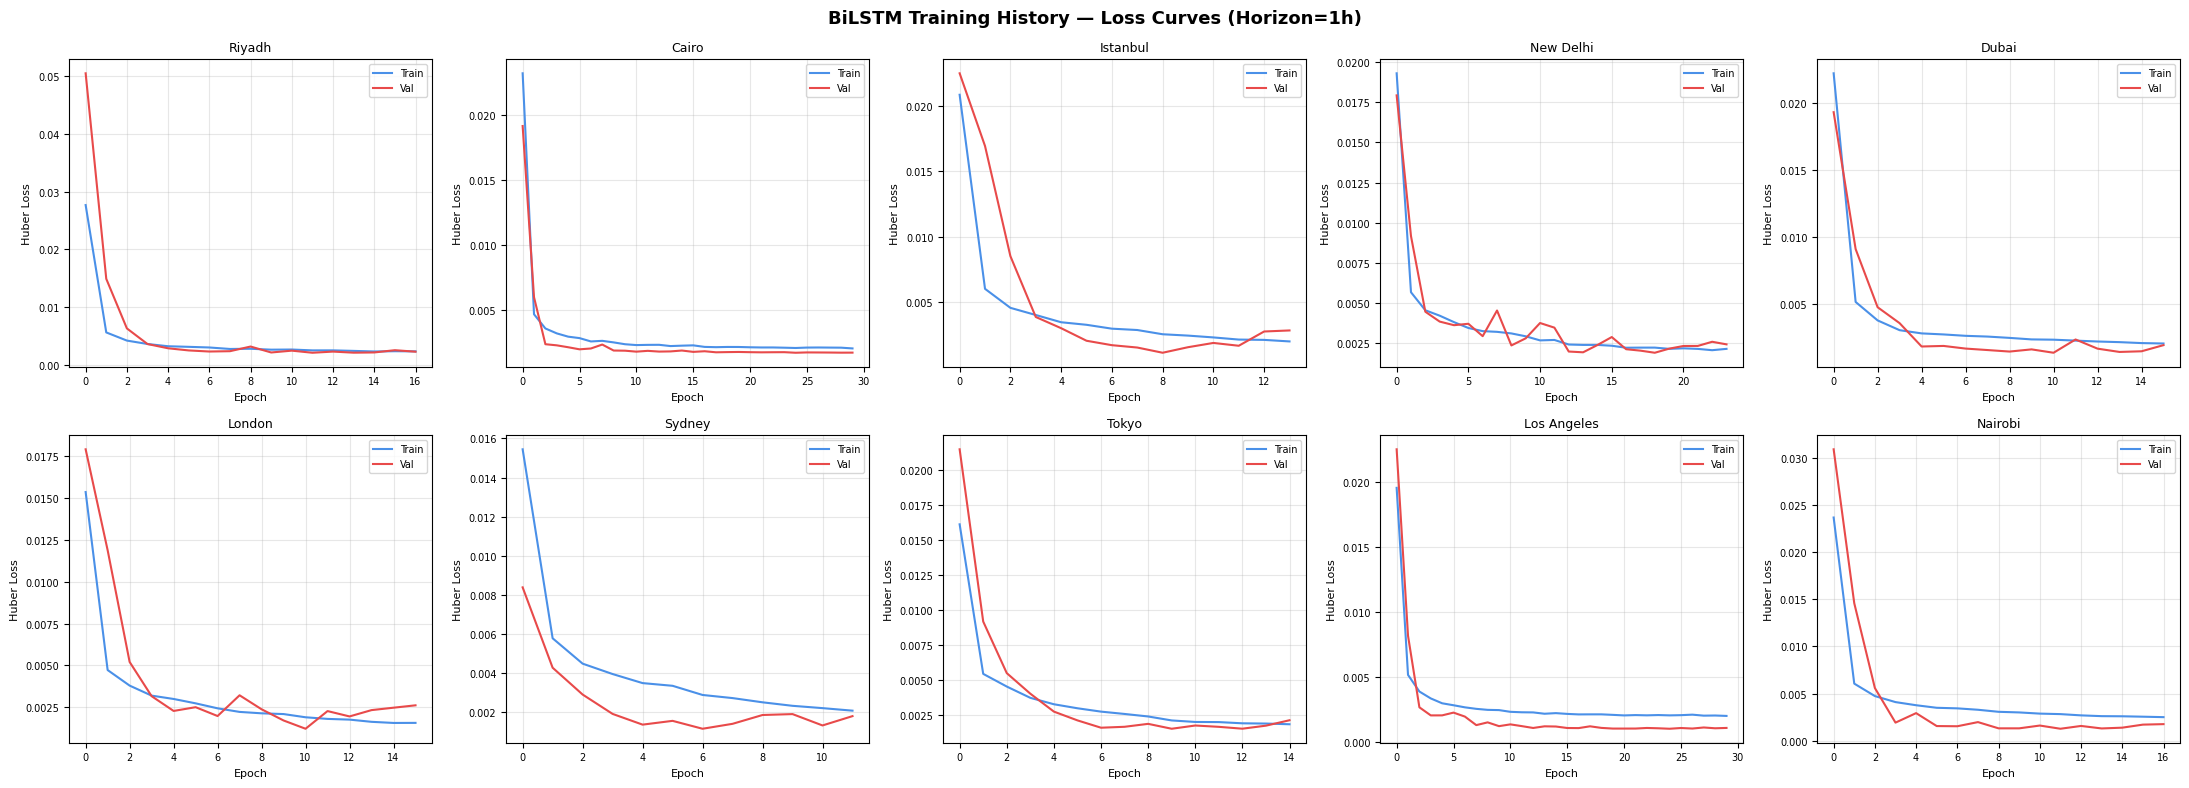

💾 Saved → ..\outputs/plots\07_lstm_training_history.png


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle(
    "BiLSTM Training History — Loss Curves (Horizon=1h)",
    fontsize=13, fontweight="bold"
)

for idx, city in enumerate(CITIES):
    ax  = axes[idx // 5][idx % 5]
    key = f"{city}_h1"

    if key in histories:
        h = histories[key]
        ax.plot(h["loss"],     label="Train", color="#4A90E8", lw=1.5)
        ax.plot(h["val_loss"], label="Val",   color="#E84A4A", lw=1.5)
        ax.set_title(city.replace("_", " ").title(), fontsize=9)
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Huber Loss", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "07_lstm_training_history.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

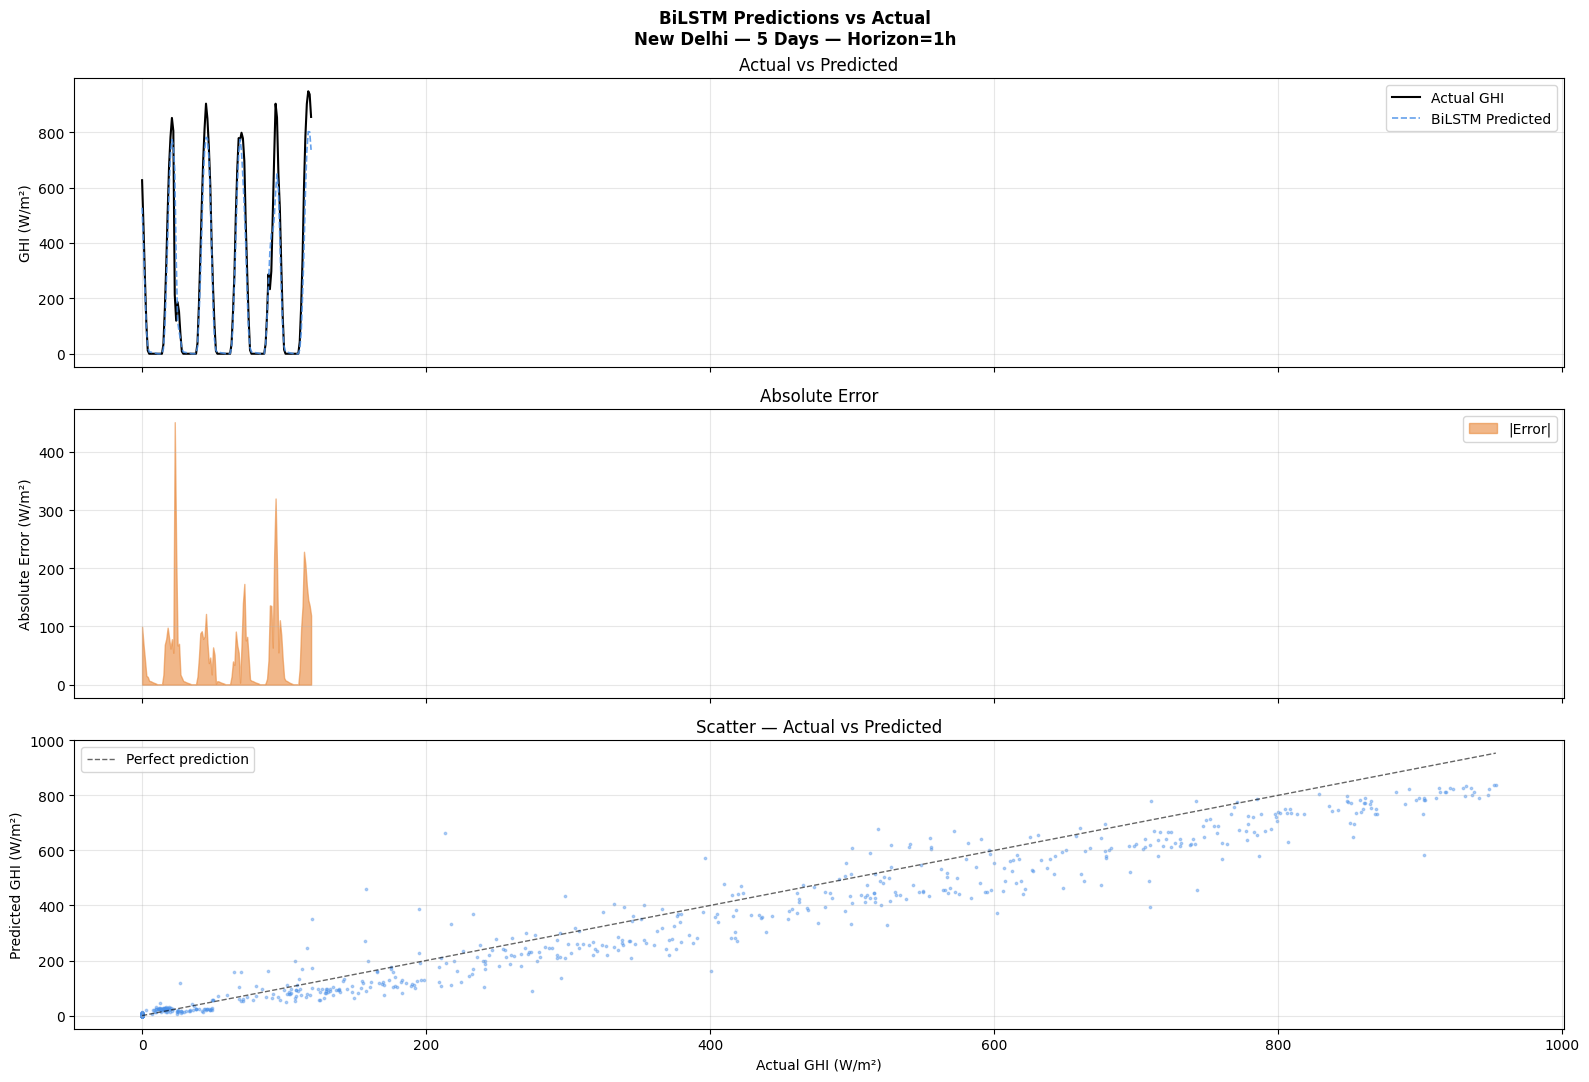


📊 New Delhi — BiLSTM h=1:
   RMSE  = 54.440 W/m²
   MAE   = 30.896 W/m²
   R²    = 0.9538
   Skill = 37.1% vs persistence

💾 Saved → ..\outputs/plots\07_lstm_predictions.png


In [14]:
# ── Cell 12 — Predictions vs Actual ──────────────────────────────
# Use the already-trained model from Cell 9 memory
# instead of reloading from disk (avoids shape mismatch)

city    = "new_delhi"
horizon = 1
df      = city_dfs[city]

(_, _, _, _, X_te, y_te,
 scaler, test_df) = prepare_city_data(
    df, SEQUENCE_FEATURES, TARGET, PAST_HOURS, horizon
)

# Find the model trained for new_delhi h=1 in the loop
# It's the last model trained for this city+horizon
# Rebuild and reload from checkpoint directly
model = build_lstm_model(
    input_shape=(PAST_HOURS, X_te.shape[2]),
    horizon=horizon,
)

ckpt_path = os.path.join(
    CKPT_DIR, f"lstm_{city}_h{horizon}.keras"
)
model.load_weights(ckpt_path)

preds_scaled = model.predict(X_te, verbose=0).flatten()
y_pred = inverse_scale_ghi(
    preds_scaled, scaler, scaler.n_features_in_
)
y_true = inverse_scale_ghi(
    y_te.flatten(), scaler, scaler.n_features_in_
)
y_pred = np.clip(y_pred, 0, None)

n_plot = 24 * 5
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle(
    f"BiLSTM Predictions vs Actual\n"
    f"{city.replace('_',' ').title()} — 5 Days — Horizon=1h",
    fontsize=12, fontweight="bold"
)
t = np.arange(n_plot)

axes[0].plot(t, y_true[:n_plot], color="black",
             lw=1.5, label="Actual GHI")
axes[0].plot(t, y_pred[:n_plot], color="#4A90E8",
             lw=1.2, linestyle="--",
             label="BiLSTM Predicted", alpha=0.85)
axes[0].set_ylabel("GHI (W/m²)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(
    t,
    np.abs(y_pred[:n_plot] - y_true[:n_plot]),
    color="#E8883A", alpha=0.6, label="|Error|"
)
axes[1].set_ylabel("Absolute Error (W/m²)")
axes[1].set_title("Absolute Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(
    y_true[:1000], y_pred[:1000],
    s=3, alpha=0.4, color="#4A90E8"
)
lim = max(y_true[:1000].max(), y_pred[:1000].max())
axes[2].plot([0, lim], [0, lim], "k--",
             lw=1, alpha=0.6, label="Perfect prediction")
axes[2].set_xlabel("Actual GHI (W/m²)")
axes[2].set_ylabel("Predicted GHI (W/m²)")
axes[2].set_title("Scatter — Actual vs Predicted")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "07_lstm_predictions.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()

m = compute_metrics(y_true, y_pred, "BiLSTM_NewDelhi_h1")
print(f"\n📊 New Delhi — BiLSTM h=1:")
print(f"   RMSE  = {m['RMSE']:.3f} W/m²")
print(f"   MAE   = {m['MAE']:.3f} W/m²")
print(f"   R²    = {m['R2']:.4f}")
print(f"   Skill = {m['Skill']:.1f}% vs persistence")
print(f"\n💾 Saved → {path}")

In [13]:
print("=" * 65)
print("  NOTEBOOK 07 — COMPLETE")
print("=" * 65)

h1_results = lstm_df[lstm_df.horizon == 1]
print(f"\n  BiLSTM h=1 summary across all cities:")
print(f"  {'City':<14} {'RMSE':>8} {'MAE':>8} "
      f"{'R²':>8} {'Skill':>8}")
print(f"  {'─'*14} {'─'*8} {'─'*8} {'─'*8} {'─'*8}")

for _, row in h1_results.iterrows():
    print(f"  {row['city']:<14} "
          f"{row['RMSE']:>8.3f} "
          f"{row['MAE']:>8.3f} "
          f"{row['R2']:>8.4f} "
          f"{row['Skill']:>7.1f}%")

mean_rmse  = h1_results["RMSE"].mean()
mean_skill = h1_results["Skill"].mean()
print(f"\n  Mean RMSE  across cities : {mean_rmse:.3f} W/m²")
print(f"  Mean Skill across cities : {mean_skill:.1f}%")
print(f"\n  Models saved to : {MODELS_DIR}")
print(f"\n  Ready for → 08_neurospike_snn.ipynb")

  NOTEBOOK 07 — COMPLETE

  BiLSTM h=1 summary across all cities:
  City               RMSE      MAE       R²    Skill
  ────────────── ──────── ──────── ──────── ────────
  riyadh           38.093   22.177   0.9872    65.6%
  cairo            40.574   19.416   0.9840    60.6%
  istanbul         37.680   23.392   0.9793    52.8%
  new_delhi        54.440   30.896   0.9538    37.1%
  dubai            34.705   18.428   0.9862    65.0%
  london           41.407   22.437   0.9564    28.7%
  sydney           60.494   33.865   0.9537    34.8%
  tokyo            46.015   26.402   0.9642    43.1%
  los_angeles      49.663   26.418   0.9743    49.0%
  nairobi          52.124   30.681   0.9707    50.2%

  Mean RMSE  across cities : 45.520 W/m²
  Mean Skill across cities : 48.7%

  Models saved to : ..\models/saved

  Ready for → 08_neurospike_snn.ipynb
